In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Smart-Warehouse-Delay/train.csv')
df

,ID,layout_id,scenario_id,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
0,TRAIN_000000,WH_136,SC_07598,51.0,96.0,3.29,0.1176,0.1765,0.0392,0.3063,...,NaN,NaN,4.60,0.1443,8.1,7.92,86.6,0.0787,5.12,NaN
1,TRAIN_000001,WH_136,SC_07598,NaN,93.0,2.55,0.0597,NaN,0.0149,NaN,...,2.50,0.2490,5.22,0.1400,NaN,5.48,83.9,0.0850,5.77,94.88
2,TRAIN_000002,WH_136,SC_07598,92.0,115.0,2.49,0.0652,0.2283,0.0217,0.3063,...,3.87,0.1977,4.26,0.1817,10.7,6.88,82.1,0.1052,NaN,94.40
3,TRAIN_000003,WH_136,SC_07598,77.0,110.0,2.52,0.0649,NaN,0.0390,0.3063,...,2.50,0.1955,4.89,0.1485,10.7,6.76,87.9,0.0920,4.53,93.72
4,TRAIN_000004,WH_136,SC_07598,NaN,122.0,3.12,0.0667,0.3333,NaN,0.3063,...,NaN,0.2351,5.16,0.1514,12.4,9.03,83.8,0.0843,3.99,95.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TRAIN_249995,WH_174,SC_05114,39.0,NaN,2.28,0.0513,0.1795,NaN,NaN,...,8.10,0.2586,4.17,0.0856,16.0,9.47,99.0,NaN,4.47,97.13
249996,TRAIN_249996,WH_174,SC_05114,69.0,96.0,2.22,0.0870,0.2319,0.0290,0.2226,...,8.63,0.2783,5.61,0.0526,19.6,11.41,NaN,0.0438,NaN,96.73
249997,TRAIN_249997,WH_174,SC_05114,61.0,123.0,2.62,0.0984,0.3934,0.0820,0.2226,...,NaN,0.2659,4.94,0.0379,16.5,13.26,95.9,NaN,3.24,98.86
249998,TRAIN_249998,WH_174,SC_05114,54.0,97.0,2.65,0.1296,0.1667,0.0185,0.2226,...,9.39,0.1736,4.40,0.0320,20.2,11.04,98.7,0.0519,1.97,98.63


# 
### **📦 1. 주문 / 수요 관련**
* order_inflow_15m → 15분 동안 들어온 주문 수
* unique_sku_15m → 15분 동안 등장한 SKU 종류 수
* avg_items_per_order → 주문당 평균 상품 개수
* urgent_order_ratio → 긴급 주문 비율
* bulk_order_ratio → 대량 주문 비율
* order_wave_count → 주문 묶음(웨이브) 개수
* pick_list_length_avg → 평균 피킹 리스트 길이
* express_lane_util → 빠른 처리 라인 사용률 👉 주문량 + 복잡도 = 지연의 핵심 원인

In [3]:
order = df[["order_inflow_15m","unique_sku_15m","avg_items_per_order",
        "urgent_order_ratio","bulk_order_ratio","order_wave_count",
        "pick_list_length_avg","express_lane_util"]]
order

,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,bulk_order_ratio,order_wave_count,pick_list_length_avg,express_lane_util
0,51.0,96.0,3.29,0.1176,0.0994,10.0,5.67,0.1305
1,NaN,93.0,2.55,0.0597,0.0651,11.0,7.74,0.2778
2,92.0,115.0,2.49,0.0652,0.0285,13.0,10.06,0.0958
3,77.0,110.0,2.52,0.0649,0.0576,8.0,11.53,0.1415
4,NaN,122.0,3.12,0.0667,NaN,6.0,8.05,0.1868
...,...,...,...,...,...,...,...,...
249995,39.0,NaN,2.28,0.0513,0.3197,6.0,6.68,0.0569
249996,69.0,96.0,2.22,0.0870,0.3199,NaN,8.55,0.0966
249997,61.0,123.0,2.62,0.0984,NaN,NaN,9.53,0.1420
249998,54.0,97.0,2.65,0.1296,NaN,4.0,6.42,0.1439


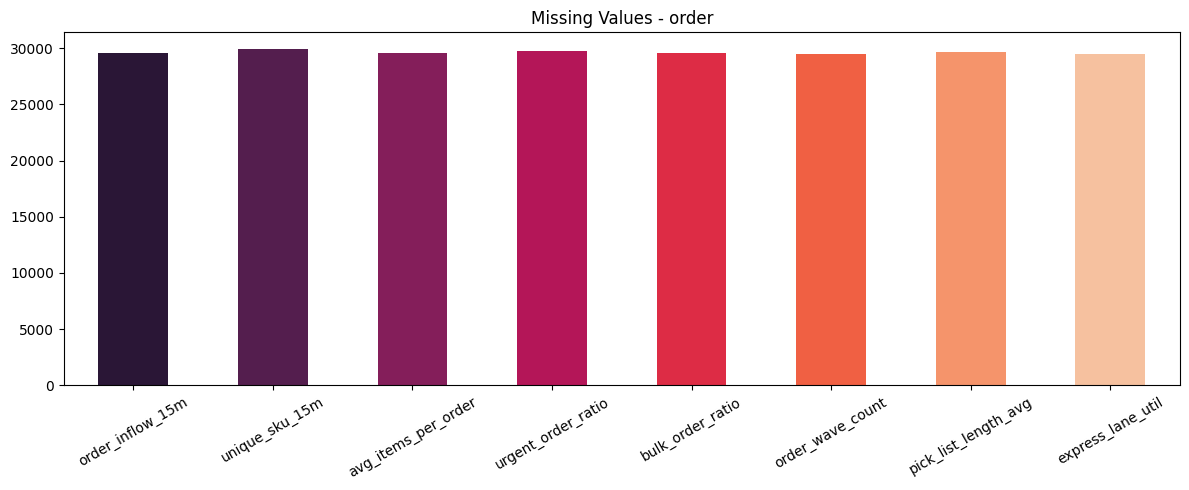

In [4]:
missing = order.isnull().sum()

colors = sns.color_palette("rocket", len(missing))

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color=colors)

plt.title('Missing Values - order')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 
### **강한 상관관계**
order_inflow_15m ↔ urgent_order_ratio = **0.65**  
urgent_order_ratio ↔ express_lane_util = 0.57  

In [5]:
corr = order.corr()
corr

,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,bulk_order_ratio,order_wave_count,pick_list_length_avg,express_lane_util
order_inflow_15m,1.000000,0.502015,-0.207321,0.645663,-0.090265,0.458881,-0.109259,0.372033
unique_sku_15m,0.502015,1.000000,0.442517,0.223833,0.205317,0.239147,0.232524,0.122292
avg_items_per_order,-0.207321,0.442517,1.000000,-0.142510,0.435069,-0.079454,0.521771,-0.095055
urgent_order_ratio,0.645663,0.223833,-0.142510,1.000000,-0.071371,0.296229,-0.076182,0.568129
bulk_order_ratio,-0.090265,0.205317,0.435069,-0.071371,1.000000,-0.030473,0.231232,-0.043931
order_wave_count,0.458881,0.239147,-0.079454,0.296229,-0.030473,1.000000,-0.050670,0.174979
pick_list_length_avg,-0.109259,0.232524,0.521771,-0.076182,0.231232,-0.050670,1.000000,-0.055907
express_lane_util,0.372033,0.122292,-0.095055,0.568129,-0.043931,0.174979,-0.055907,1.000000


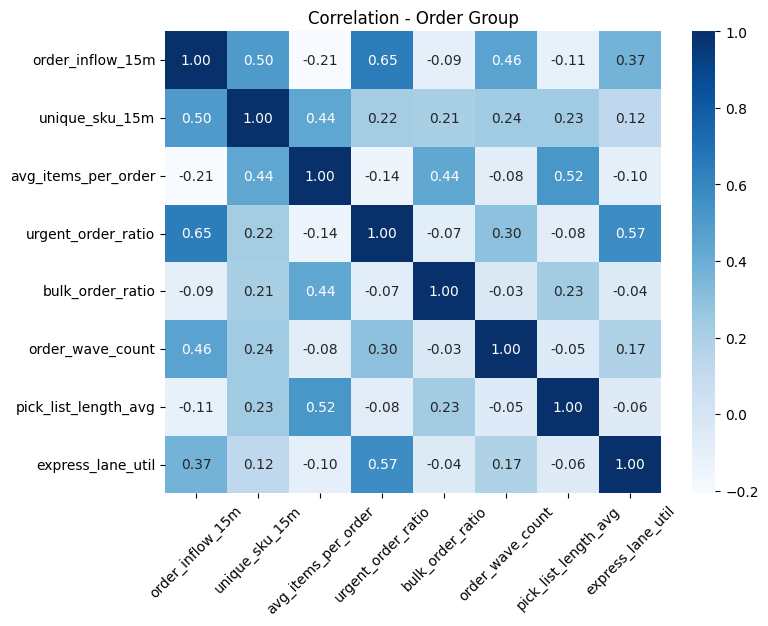

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")

plt.title('Correlation - Order Group')
plt.xticks(rotation=45)
plt.show()